In [1]:
import pandas as pd
import numpy as np
import os
from tqdm import tqdm
import math
import re

import sys
sys.path.append('../../../')
from mount_drive import mount_s_drive

In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Model
from sklearn.datasets import make_classification


2025-06-05 20:37:36.838809: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-05 20:37:36.842256: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-06-05 20:37:36.850518: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1749170256.872140     160 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1749170256.876442     160 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-05 20:37:36.891231: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [3]:
import pandas as pd
import os
import sys
dir1 = os.path.abspath(os.path.join(os.getcwd(), '../../analysisFunctions'))
# dir2 = os.path.abspath(os.path.join(os.getcwd(), '../GANITE'))
sys.path.insert(0, dir1)
# sys.path.insert(0, dir2)
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from sklearn.feature_selection import VarianceThreshold

from statsmodels.stats.multicomp import pairwise_tukeyhsd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, roc_auc_score, make_scorer, auc, roc_curve
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from xgboost import XGBClassifier, XGBRegressor, plot_tree, plot_importance, to_graphviz
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.impute import SimpleImputer
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from graphviz import Source
from sklearn import tree
from sklearn.svm import SVC, LinearSVC, SVR
import re
from machine_learning import *
# from hyperion_utils import *
# from bartpy.sklearnmodel import SklearnModel
# import doubleml as dml
# import pymc as pm
# import pymc_bart as pmb
from sklearn.neighbors import KNeighborsRegressor
# from pybart.api import BART
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import chi2
# from econml.dml import CausalForestDML
# import causalpy as cp
# import pymc_bart as pmb
from sklearn.cluster import KMeans,AgglomerativeClustering, SpectralClustering, MeanShift, DBSCAN 
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
warnings.filterwarnings('ignore', category=DeprecationWarning)
import random
from stepmix.stepmix import StepMix
from sklearn.metrics import silhouette_score
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.impute import KNNImputer
from eICUUtil import *
from sklearn.decomposition import PCA

/home/idies/miniconda3/lib/python3.9/site-packages/xgboost/core.py:265: FutureWarning: Your system has an old version of glibc (< 2.28). We will stop supporting Linux distros with glibc older than 2.28 after **May 31, 2025**. Please upgrade to a recent Linux distro (with glibc 2.28+) to use future versions of XGBoost.
Note: You have installed the 'manylinux2014' variant of XGBoost. Certain features such as GPU algorithms or federated learning are not available. To use these features, please upgrade to a recent Linux distro with glibc 2.28+, and install the 'manylinux_2_28' variant.
  warnings.warn(


In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np

def getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', aTreatmentColumn = 'Hypothermia', aTestSize = 0.3, aTreatmentSplit = False, aDropColumns = [], aSkipTemp = True):
    myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')

    # Preprocessing
    myFilter = (myPredictorsDf['LastMGCS'] != 'Unable to score due to medication') & (~myPredictorsDf['LastMGCS'].isna())
    myFilter = myFilter & (myPredictorsDf['FirstMGCSTime'] != myPredictorsDf['LastMGCSTime']) #& (myPredictorsDf['FirstMGCSTime'] < 360)
    myPredictorsDf.loc[myPredictorsDf['FirstGCS'] == 'Unable to score due to medication', 'FirstGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['FirstMGCS'] == 'Unable to score due to medication', 'FirstMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastMGCS'] == 'Unable to score due to medication', 'LastMGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['LastGCS'] == 'Unable to score due to medication', 'LastGCS'] = np.nan
    myPredictorsDf.loc[myPredictorsDf['DeathAtDischarge'] == 1, 'LastMGCS'] = 1
    myPredictorsDf.gender = (myPredictorsDf.gender == 'Male').astype(int)
    myPredictorsDf.LastGCS15 = 0
    myPredictorsDf.loc[myFilter, 'LastMGCSPositive'] = (myPredictorsDf.loc[myFilter, 'LastMGCS'].astype(float) == 6).astype(int)

    myBinaryColumns = myPredictorsDf.columns[myPredictorsDf.nunique() == 2] 
    myBinaryDf = myPredictorsDf[myBinaryColumns]
    myBinaryDf = myBinaryDf.select_dtypes(exclude=["object"])
    myLowColumns = myBinaryDf.columns[(myBinaryDf.sum() < 15)]
    myPredictorsDf.drop(columns=list(myLowColumns) + aDropColumns, inplace=True)

    myGcs15Fitler = (myPredictorsDf.nurse_first_Motor != 6)

    if (aPredictedColumn == 'LastMGCSPositive'):
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & myFilter & ~myPredictorsDf[aTreatmentColumn].isna()]
    else:
        myPredictorsDf = myPredictorsDf[myGcs15Fitler & ~myPredictorsDf[aPredictedColumn].isna() & ~myPredictorsDf[aTreatmentColumn].isna()]

    myColumns = []
    if (aSkipTemp):
        myColumns = [x for x in myPredictorsDf.columns if 'emp' in x]

    # Get output data
    myXValue = myPredictorsDf.drop(columns= myColumns + ['FirstGCS', 'FirstMGCS', 'LastMGCSTime', 'FirstMGCSTime', 'LastMGCSPositive', 'LastMGCS' , 'apacheadmissiondx', 'hospitaladmittime24', 'FirstGCSTime', 'LastGCSTime', 'LastGCS', 'hospitaldischargestatus', 'LastGCS15', 'hospitaladmitsource', 'DeathAtDischarge', 'patientunitstayid'])
    myXValue = myXValue
    # myXValue.FirstGCS = myXValue.FirstGCS.astype(float)
    # myXValue.FirstMGCS = myXValue.FirstMGCS.astype(float)
    myXValue = myXValue.select_dtypes(exclude=['object'])
    myYValue = myPredictorsDf[aPredictedColumn]
    myYValue = myYValue.astype(int)

    if (aTreatmentSplit):
        myXValue = myXValue.drop(columns=[aTreatmentColumn])
        X_train, X_test, T_train, T_test, y_train, y_test = train_test_split(myXValue, myPredictorsDf[aTreatmentColumn], myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, T_train, T_test, y_train, y_test
    else:
        X_train, X_test, y_train, y_test = train_test_split(myXValue, myYValue, stratify=myPredictorsDf[[aPredictedColumn, aTreatmentColumn]], test_size=aTestSize)
        return myPredictorsDf, X_train, X_test, y_train, y_test

In [5]:
myTreatmentColumn = 'treatment_hypothermia'
myPredictorsDf, X_train, X_test, y_train, y_test = getTrainTestFunctions(aPredictedColumn = 'LastMGCSPositive', 
                                                                         aTreatmentColumn = myTreatmentColumn, 
                                                                         aDropColumns=['Hypothermia', 'both_hypothermia', 'treatment_therapy for controlling cerebral perfusion pressure', 
                                                                                         'treatment_neurologic', 'treatment_neuromuscular blocking agent', 'treatment_subcutaneous'], 
                                                                         aSkipTemp = True) 

/tmp/ipykernel_160/2444830225.py:6: DtypeWarning: Columns (2059,2070,2081,2083,2084,2089,2095,2099,2108,2119,2130,2132,2133,2138,2144,2148,2305,2307) have mixed types. Specify dtype option on import or set low_memory=False.
  myPredictorsDf = pd.read_csv('eICUPredictorsDiag.csv')


In [6]:
[x for x in X_train.columns if 'gcs' in x.lower()]
 

['nurse_max_GCS Total', 'nurse_min_GCS Total', 'nurse_mean_GCS Total']

In [7]:
def getCovariatePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = PCA(0.99)
        )
def getVariancePreprocessor(aKeepColumns):
    return    ColumnTransformer(
            transformers=[
                ('keep', 'passthrough', aKeepColumns), 
            ],
            remainder = VarianceThreshold(0.01)
        )

In [8]:
def getDefaultPipelineSteps(X_train):
    myNumericalColumns = X_train.columns[(X_train.nunique() > 5) & (X_train.dtypes != object)]
    myBinaryColumns = X_train.columns[X_train.nunique() == 2]
    myPreprocessor = getDefaultPreprocessor(aNumericalColumns=myNumericalColumns, aBinaryColumns=myBinaryColumns)
    myPreprocessor.set_output(transform="pandas")
    myImputer = KNNImputer(n_neighbors=50)
    myImputer.set_output(transform="pandas")
    myBinaryColumns  = ['bin__' + x for x in myBinaryColumns]
    myCovariates = getCovariatePreprocessor(['keep__bin__' + myTreatmentColumn])
    myCovariates.set_output(transform="pandas")
    myVariance = getVariancePreprocessor(['bin__' + myTreatmentColumn])
    myVariance.set_output(transform="pandas")
    return [('preprocessor', myPreprocessor),  ('variance', myVariance), ('imputer', myImputer), ('covariates', myCovariates)]

In [9]:
# X_train = X_train.loc[:, X_train.isnull().mean() < 0.5]
# X_test = X_test[X_train.columns]

In [10]:
myPipeline = Pipeline(getDefaultPipelineSteps(X_train))
X_train_transf = myPipeline.fit_transform(X_train, y_train)
X_test_transf = myPipeline.transform(X_test)
X_train_transf = pd.DataFrame(X_train_transf, columns = myPipeline.get_feature_names_out())
X_test_transf = pd.DataFrame(X_test_transf, columns = myPipeline.get_feature_names_out())

In [11]:
X_train_transf.shape

(1455, 361)

In [12]:
[x for x in X_train_transf.columns if 'hyp'in x]

['keep__keep__bin__treatment_hypothermia']

In [13]:
model = keras.Sequential([
    keras.Input(shape=(X_train_transf.shape[1],)),  
    layers.Dense(64, activation='relu'), 
    layers.Dropout(0.5),
    layers.Dense(32, activation='relu'), 
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid') 
])
# from tensorflow.keras.callbacks import EarlyStopping

# early_stopping = EarlyStopping(
#     monitor='loss',  # Metric to track
#     patience=10,          # Number of epochs to wait before stopping
#     restore_best_weights=True  # Restore the best model weights
# )

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy', tf.keras.metrics.AUC(name="roc_auc")])


2025-06-05 20:38:17.772268: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [14]:
history = model.fit(X_train_transf, y_train.reset_index().drop(columns='index'), epochs=15, batch_size=32, validation_data=(X_test_transf, y_test.reset_index().drop(columns='index')))#, callbacks=[early_stopping])

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5324 - loss: 0.9226 - roc_auc: 0.4742 - val_accuracy: 0.6763 - val_loss: 0.6113 - val_roc_auc: 0.6419
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6329 - loss: 0.7571 - roc_auc: 0.5844 - val_accuracy: 0.6955 - val_loss: 0.5852 - val_roc_auc: 0.7044
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6747 - loss: 0.6749 - roc_auc: 0.6168 - val_accuracy: 0.7131 - val_loss: 0.5679 - val_roc_auc: 0.7359
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6606 - loss: 0.6209 - roc_auc: 0.6806 - val_accuracy: 0.7212 - val_loss: 0.5589 - val_roc_auc: 0.7512
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6800 - loss: 0.5875 - roc_auc: 0.7094 - val_accuracy: 0.7099 - val_loss: 0.5476 - val_roc_auc: 0.7605
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7152 - loss: 0.5593 - roc_auc: 0.7470 - val_accuracy: 0.7228 - val_loss: 0.5373 - val_roc_auc: 0.7709
Epo

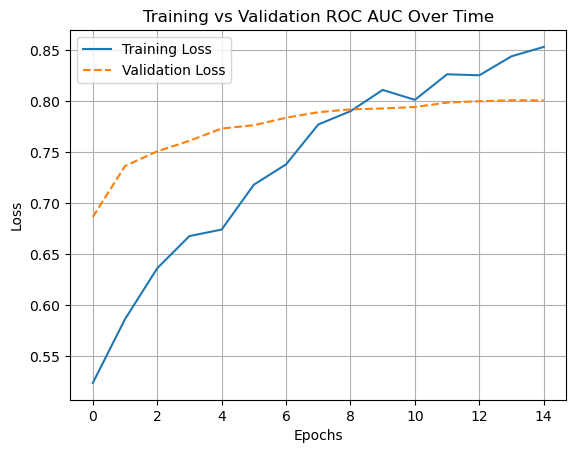

In [132]:
# Extract loss values
train_loss = history.history['roc_auc']
val_loss = history.history['val_roc_auc']

# Plot training & validation loss
plt.plot(train_loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss', linestyle='dashed')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation ROC AUC Over Time')
plt.legend()
plt.grid(True)
plt.show()

In [133]:
y_pred_probs = model.predict(X_test_transf)  # Probabilities

# Compute ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_probs)
print(f"ROC AUC Score: {roc_auc:.4f}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
ROC AUC Score: 0.8008


In [134]:
y_pred_probs.T[0, :]

array([2.38821894e-01, 1.14502490e-01, 5.23812950e-01, 2.37874284e-01,
       6.56634048e-02, 5.99116802e-01, 6.13836765e-01, 4.08096105e-01,
       6.71724498e-01, 2.04298683e-02, 5.25810599e-01, 4.53265935e-01,
       1.53847458e-02, 1.44094199e-01, 6.86384380e-01, 4.27420974e-01,
       5.75093269e-01, 2.22024377e-02, 4.69796807e-01, 6.65563047e-02,
       5.45960963e-01, 3.62328231e-01, 4.29707706e-01, 4.26394213e-03,
       2.29636759e-01, 3.14045660e-02, 1.32966256e-02, 6.67098224e-01,
       9.76762101e-02, 4.28350061e-01, 5.30187488e-01, 6.70317352e-01,
       7.27506936e-01, 3.14295799e-01, 1.89031824e-01, 2.20265046e-01,
       4.27958816e-01, 2.90875435e-01, 9.04896200e-01, 5.01024842e-01,
       2.52927661e-01, 3.42156678e-01, 4.27580215e-02, 2.89723247e-01,
       2.47179896e-01, 7.06906850e-03, 7.15747625e-02, 3.88147347e-02,
       2.73717314e-01, 6.44943416e-01, 7.51263201e-01, 2.08633140e-01,
       2.39739925e-01, 1.29625842e-01, 7.97075748e-01, 2.53910154e-01,
      

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Optimization terminated successfully.
         Current function value: 0.632019
         Iterations 5
Optimization terminated successfully.
         Current function value: 0.631214
         Iterations 6
Likelihood ratio of test results:
Chi square statistic: 2.3425531236616735
p-value: 0.12588308541450147
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       LastMGCSPositive   No. Observations:                 1455
Model:                          Logit   Df Residuals:                     1452
Method:                           MLE   Df Model:                            2
Date:                Thu, 05 Jun 2025   Pseudo R-squ.:                0.008540
Time:                        20:22:50   Log-Likelihood:                -919.59
converged:                       True   LL-Null:                       -927.51
Covariance Type:    

0.12588308541450147

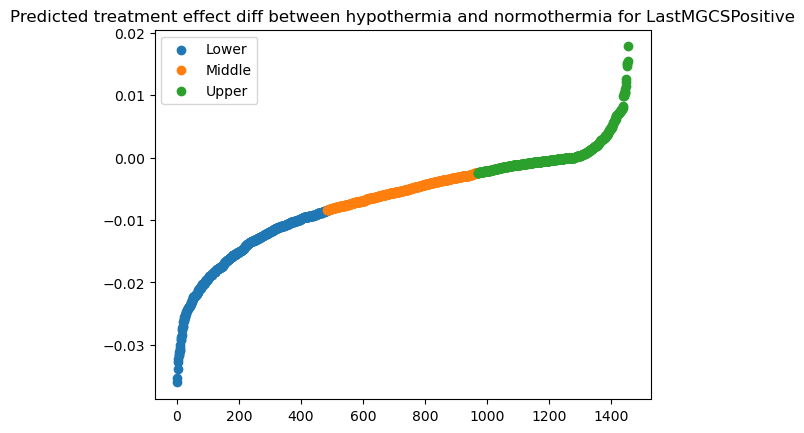

In [135]:
getTreatmentEffectDiff(aX = X_train_transf, aY = y_train.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'LastMGCSPositive', aGroup = 'keep__keep__bin__treatment_hypothermia', aUseNeuralNetwork = True, aByGroup = False)

20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
Optimization terminated successfully.
         Current function value: 0.686423
         Iterations 4
Optimization terminated successfully.
         Current function value: 0.684580
         Iterations 5
Likelihood ratio of test results:
Chi square statistic: 2.300295876159339
p-value: 0.1293493570959976
Degress of freedom: 1.0
No interaction                            Logit Regression Results                           
Dep. Variable:       DeathAtDischarge   No. Observations:                  624
Model:                          Logit   Df Residuals:                      621
Method:                           MLE   Df Model:                            2
Date:                Sun, 01 Jun 2025   Pseudo R-squ.:                0.007043
Time:                        23:33:24   Log-Likelihood:                -428.33
converged:                       True   LL-Null:                       -431.37
Covariance Type:      

0.1293493570959976

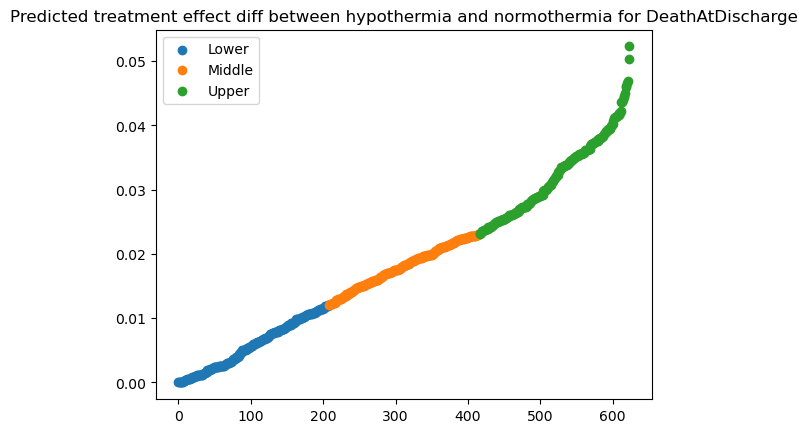

In [54]:
getTreatmentEffectDiff(aX = X_test_transf, aY = y_test.reset_index().drop(columns='index'), aModel = model, \
                       aCategory = 'DeathAtDischarge', aGroup = 'keep__keep__bin__treatment_hypothermia', aUseNeuralNetwork = True, aByGroup = False)

In [87]:
myGroup = myNewDf.groupby(['predicted_effect_group', myTreatment]).agg({myPredicted:'sum', 'index':'count'})
myGroup = myGroup.reset_index()
myGroup['percent'] = myGroup[myPredicted] / myGroup['index']
myGroup
# does not mean anything because you don't know the baseline effect

NameError: name 'myNewDf' is not defined

In [55]:
pip install shap


Note: you may need to restart the kernel to use updated packages.


In [19]:
y_test.sum()

209

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


  0%|          | 0/10 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step
8657/8657 ━━━━━━━━━━━━━━━━━━━━ 7s 841us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
8657/8657 ━━━━━━━━━━━━━━━━━━━━ 7s 807us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
8657/8657 ━━━━━━━━━━━━━━━━━━━━ 8s 891us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
8657/8657 ━━━━━━━━━━━━━━━━━━━━ 7s 773us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
8657/8657 ━━━━━━━━━━━━━━━━━━━━ 7s 834us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step
8657/8657 ━━━━━━━━━━━━━━━━━━━━ 8s 875us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
8657/8657 ━━━━━━━━━━━━━━━━━━━━ 7s 836us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
8657/8657 ━━━━━━━━━━━━━━━━━━━━ 7s 782us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
8657/8657 ━━━━━━━━━━━━━━━━━━━━ 7s 816us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
8657/8657 ━━━━━━━━━━━━━━━━━━━━ 7s 817us/step


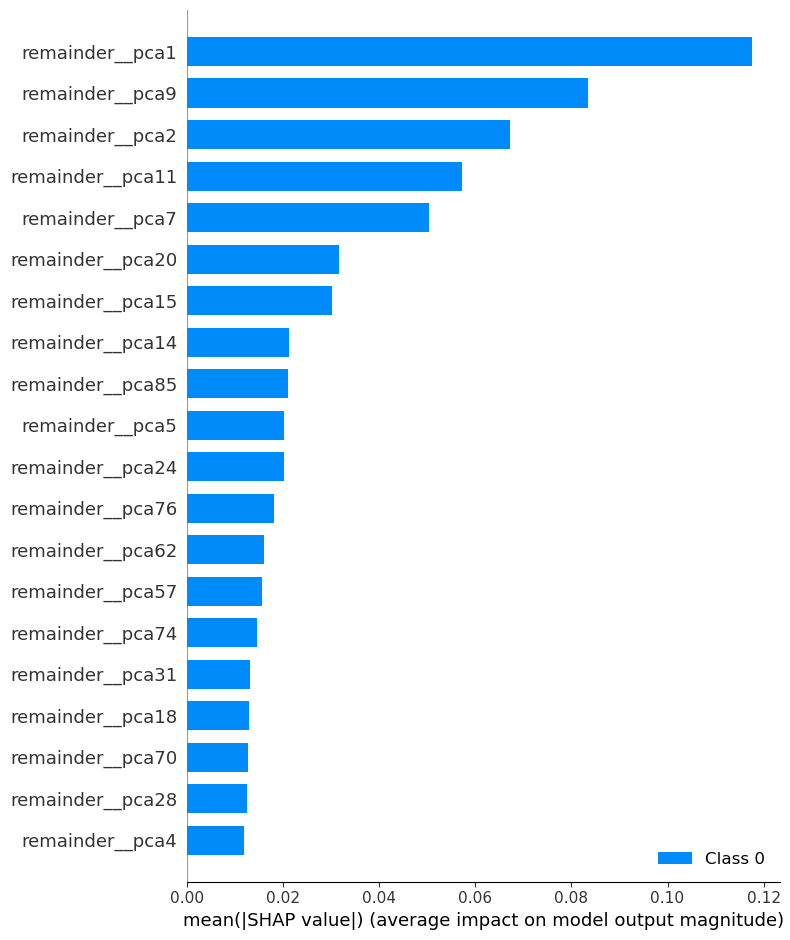

In [30]:
import shap
import numpy as np

# Use a small representative background set
X_background = X_test_transf[:100]
X_explain = X_test_transf[:10]

# shap needs a prediction function that outputs a 2D array
explainer = shap.KernelExplainer(model.predict, X_background)
shap_values = explainer.shap_values(X_explain)

shap.summary_plot(shap_values, X_explain)


In [32]:
feature_name = "keep__keep__bin__treatment_hypothermia"
feature_index = X_explain.columns.get_loc(feature_name)

# Mean absolute SHAP value for this feature
importance_score = np.abs(shap_values[0][:, feature_index]).mean()
print(f"Mean |SHAP| for {feature_name}: {importance_score:.4f}")


Mean |SHAP| for keep__keep__bin__treatment_hypothermia: 0.0042


In [34]:
import numpy as np
import pandas as pd

# 1. Compute mean absolute SHAP value for each feature
mean_abs_shap = np.abs(shap_values[0]).mean(axis=0)  # shape: (n_features,)

# 2. Create a DataFrame for easy lookup and sorting
importance_df = pd.DataFrame({
    'feature': X_explain.columns,
    'mean_abs_shap': mean_abs_shap
}).sort_values(by='mean_abs_shap', ascending=False).reset_index(drop=True)

# 3. Find the rank of a specific feature
feature_name = "keep__keep__bin__treatment_hypothermia"  # replace with your actual feature
rank = importance_df.index[importance_df['feature'] == feature_name].item() + 1
score = importance_df.loc[importance_df['feature'] == feature_name, 'mean_abs_shap'].item()

print(f"🔍 Feature '{feature_name}' is ranked #{rank} out of {X_explain.shape[1]} in importance with mean(|SHAP|) = {score:.4f}")


🔍 Feature 'keep__keep__bin__treatment_hypothermia' is ranked #81 out of 361 in importance with mean(|SHAP|) = 0.0042


In [28]:
shap_values

[array([[ 0.00260784,  0.        , -0.28369695, ...,  0.00245607,
          0.        ,  0.        ],
        [ 0.00102849,  0.00144985, -0.01620795, ...,  0.00774075,
          0.        ,  0.        ],
        [ 0.00140487,  0.        ,  0.00691172, ...,  0.00461957,
         -0.00180843,  0.0014207 ],
        ...,
        [-0.00919301,  0.        ,  0.05207853, ...,  0.        ,
          0.0013905 , -0.00229487],
        [ 0.00184096, -0.00224829,  0.23106563, ...,  0.00066136,
         -0.00035774, -0.00135713],
        [-0.00708724,  0.00138524,  0.03438432, ...,  0.00383549,
         -0.00189342,  0.0015906 ]])]

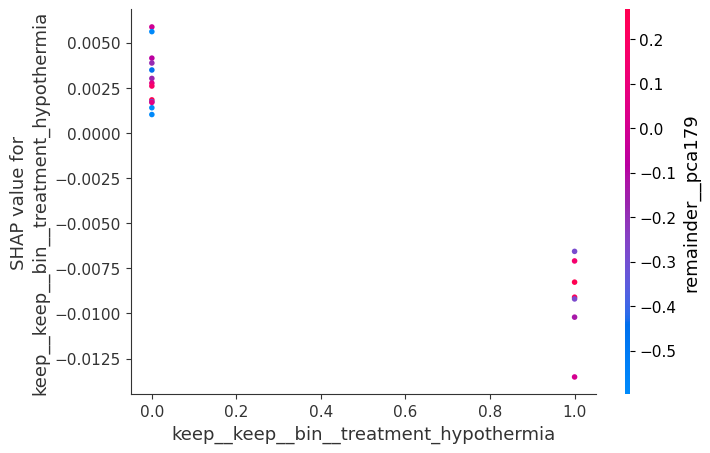

In [29]:
# Assume: shap_values = explainer.shap_values(X_explain_df)
# For binary classification: shap_values[1] = class 1 SHAP values
shap_values_class1 = shap_values[0]

# Plot interaction of 'feature_x' (you choose the name)
shap.dependence_plot("keep__keep__bin__treatment_hypothermia", shap_values_class1, X_explain)


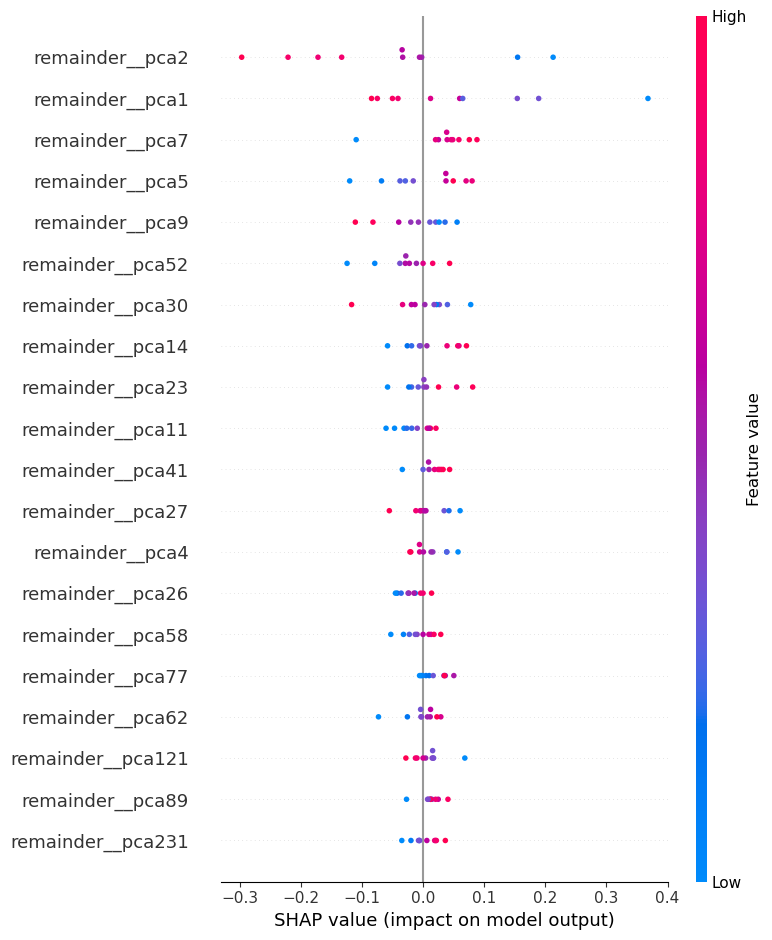

In [66]:
shap.summary_plot(shap_values[0], X_explain)